In [ ]:
# install transformer moels
%pip install accelerate transformers bertopic top2vec[sentence_transformers]
%pip install -i https://pypi.org/simple/ bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88

In [ ]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from datetime import datetime

# Tokenization tools
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from string import punctuation
import re

# Scikit-Learn
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer

# Coherence
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.utils import tokenize

In [ ]:
# class to calculate coherence score
class Metrics():

  def bert_coherence(self, sentences, topics, BERTopic_model):

    # Preprocess Documents
    documents = pd.DataFrame({
        "Document": sentences,
        "ID": range(len(sentences)),
        "Topic": topics}
    )
    documents_per_topic = documents.groupby(['Topic'], as_index=False).agg({'Document': ' '.join})
    cleaned_docs = BERTopic_model._preprocess_text(documents_per_topic.Document.values)

    # Extract vectorizer and analyzer from BERTopic
    vectorizer = BERTopic_model.vectorizer_model
    analyzer = vectorizer.build_analyzer()

    # Extract features for Topic Coherence evaluation
    words = vectorizer.get_feature_names_out()
    tokens = [analyzer(doc) for doc in cleaned_docs]
    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(token) for token in tokens]
    topic_words = []
    for topic in set(topics):
        try:
            topic_data = BERTopic_model.get_topic(topic)
            if topic_data:  # Ensure the topic is valid
                topic_words.append([word for word, _ in topic_data])
        except Exception as e:
            print(f"Error processing topic {topic}: {e}")

    # Evaluate
    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokens,
        corpus=corpus,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence = coherence_model.get_coherence()
    return coherence

  def t2v_coherence(self, sentences, topics):
      tokenized = [list(tokenize(doc)) for doc in sentences]
      id2word = corpora.Dictionary(tokenized)
      corpus = [id2word.doc2bow(text) for text in tokenized]

      # make sure you grab the topic words from the topic model and convert them to a list
      coherence_model = CoherenceModel(
          topics = topics,
          texts=tokenized,
          corpus=corpus,
          dictionary=id2word,
          coherence='c_v',
          topn=10
      )
      coherence = coherence_model.get_coherence()
      return coherence


In [ ]:
# class to create wordclouds
class AllWordClouds():

    def lda_wordcloud(self, topic, lda_model):
        wordcloud = WordCloud(background_color="white", max_words=1000, contour_width=3, contour_color='steelblue')
        texts = [x[0] for x in lda_model.show_topic(topic)]
        long_string = ','.join(texts)
        wordcloud.generate(long_string)

        return wordcloud.to_image()

In [ ]:
# read the dataset
data = pd.read_csv('boomlive_data_11_2018_to_12_2024.csv', encoding='unicode_escape')
data.head()

,Category,Link,Heading,Sub_heading,Author,Date,Claim,Fact_check,Claim_summary,Claimed_by,Fact_check_summary,Links,Year,Month
0,fact check,https://www.boomlive.in/fake-news-deja-vu-vide...,fake news dÃ©jÃ vu: video of jilted man mista...,"no, this video does not show a terrorist caugh...",BOOM FACT Check Team |,2018-11-02 18:41:00,NaN,NaN,video of a terrorist nabbed in punjab disguise...,facebook user,false,['https://web.archive.org/web/20181102093455/h...,2018,11
1,fact check,https://www.boomlive.in/image-from-2014-shared...,image from 2014 shared to claim women not safe...,images of the 2014 mohanlalganj rape-murder ca...,BOOM FACT Check Team |,2018-11-06 19:05:00,NaN,NaN,image from 2014 mohanlalganj rape-murder case ...,facebook page,false,['https://www.facebook.com/YahaSabKuchmiltaha/...,2018,11
2,fact check,https://www.boomlive.in/parody-virat-kohli-twi...,parody virat kohli twitter account endorses in...,the parody account had fans believing that ind...,Nivedita Niranjankumar |,2018-11-08 14:57:00,NaN,NaN,virat kohli discontinuing endorsing foreign br...,twitter user,false,"['https://archive.is/gZ8Vy', 'https://twitter....",2018,11
3,fact check,https://www.boomlive.in/still-from-bhojpuri-mo...,still from bhojpuri movie resurfaces with fals...,once again this photo from a movie is being sh...,BOOM FACT Check Team |,2018-11-09 14:21:00,NaN,NaN,photo of mla from uttar pradesh sexually haras...,facebook user,false,['https://timesofindia.indiatimes.com/entertai...,2018,11
4,fact check,https://www.boomlive.in/video-claiming-pm-modi...,video claiming pm modi mocked demonetisation h...,parts of speech from 2016 have been edited to ...,Nivedita Niranjankumar |,2018-11-09 14:49:00,NaN,boom found that the edited portion of the vide...,video of pm narendra modi making fun of suffer...,twitter user,false,"['https://archive.is/BvC7F', 'https://twitter....",2018,11


In [ ]:
# shape of the data
data.shape

(3607, 14)

In [ ]:
# few claims
data['Claim'].tail()

,Claim
3602,bjp delhi shared an image claiming to depict p...
3603,video shows a hindu woman who was raped and to...
3604,viral image shows former indian prime minister...
3605,video shows a couple being publicly flogged in...
3606,video shows pakistani boy marrying his mother


In [ ]:
# data types of columns
data.dtypes

,0
Category,object
Link,object
Heading,object
Sub_heading,object
Author,object
Date,object
Claim,object
Fact_check,object
Claim_summary,object
Claimed_by,object


In [ ]:
# convert date to datetime
data['Date'] = pd.to_datetime(data['Date'])

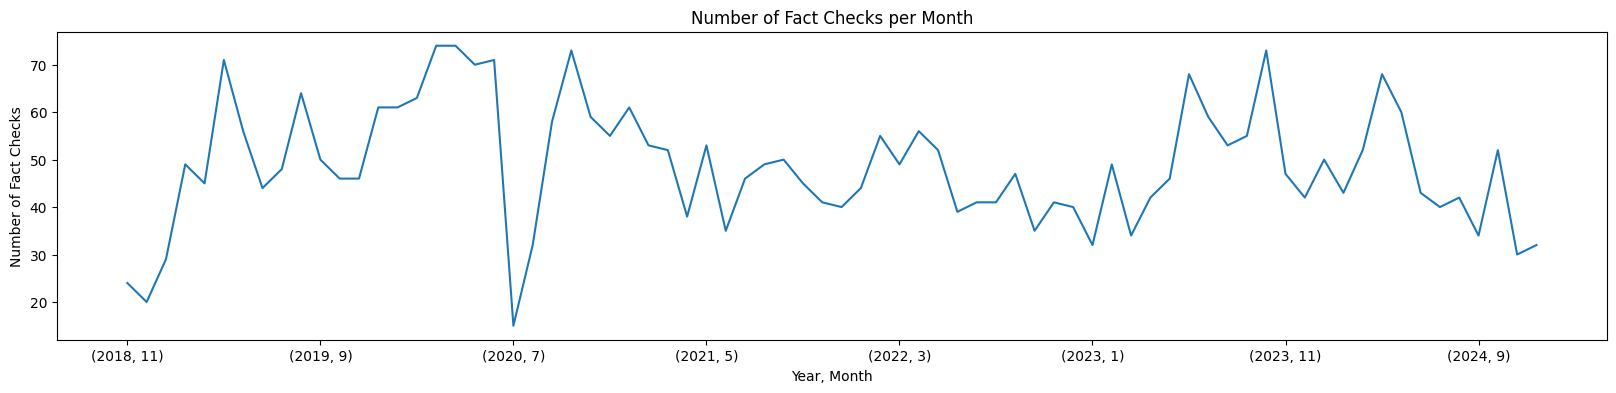

In [ ]:
# plot the number of fact checks per month
plt.figure(figsize=(20, 4))
data.groupby(['Year', 'Month']).size().plot()
plt.title('Number of Fact Checks per Month')
plt.xlabel('Year, Month')
plt.ylabel('Number of Fact Checks')
plt.show()

<ipython-input-11-0eeeb1b24f56>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Year', data=data, palette='coolwarm')


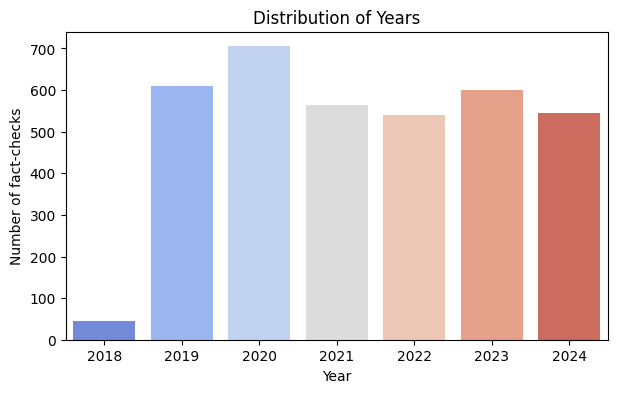

In [ ]:
# histogram of the Year column using seaborn
plt.figure(figsize=(7, 4))
sns.countplot(x='Year', data=data, palette='coolwarm')
plt.title('Distribution of Years')
plt.xlabel('Year')
plt.ylabel('Number of fact-checks')
plt.show()

In [ ]:
# convert factcheck summary to lower case
data['Fact_check_summary'] = data['Fact_check_summary'].str.lower()

<ipython-input-13-1e45a509ca63>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Fact_check_summary', data=data, palette='coolwarm')


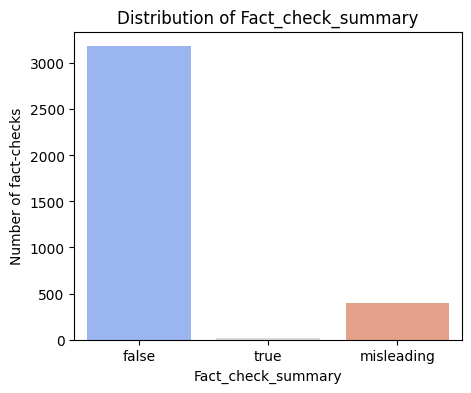

In [ ]:
# histogram of the Fact_check_summary column using seaborn
plt.figure(figsize=(5, 4))
sns.countplot(x='Fact_check_summary', data=data, palette='coolwarm')
plt.title('Distribution of Fact_check_summary')
plt.xlabel('Fact_check_summary')
plt.ylabel('Number of fact-checks')
plt.show()

In [ ]:
# length of null values in claims
data['Claim'].isnull().sum()

373

In [ ]:
# for missing claims if claim summary is available replace the null with the claim summary
data['Claim'] = data['Claim'].fillna(data['Claim_summary'])

In [ ]:
# again look for the missing claims
data['Claim'].isnull().sum()

0

In [ ]:
# few rows of the data
data.head()

,Category,Link,Heading,Sub_heading,Author,Date,Claim,Fact_check,Claim_summary,Claimed_by,Fact_check_summary,Links,Year,Month
0,fact check,https://www.boomlive.in/fake-news-deja-vu-vide...,fake news dÃ©jÃ vu: video of jilted man mista...,"no, this video does not show a terrorist caugh...",BOOM FACT Check Team |,2018-11-02 18:41:00,video of a terrorist nabbed in punjab disguise...,NaN,video of a terrorist nabbed in punjab disguise...,facebook user,false,['https://web.archive.org/web/20181102093455/h...,2018,11
1,fact check,https://www.boomlive.in/image-from-2014-shared...,image from 2014 shared to claim women not safe...,images of the 2014 mohanlalganj rape-murder ca...,BOOM FACT Check Team |,2018-11-06 19:05:00,image from 2014 mohanlalganj rape-murder case ...,NaN,image from 2014 mohanlalganj rape-murder case ...,facebook page,false,['https://www.facebook.com/YahaSabKuchmiltaha/...,2018,11
2,fact check,https://www.boomlive.in/parody-virat-kohli-twi...,parody virat kohli twitter account endorses in...,the parody account had fans believing that ind...,Nivedita Niranjankumar |,2018-11-08 14:57:00,virat kohli discontinuing endorsing foreign br...,NaN,virat kohli discontinuing endorsing foreign br...,twitter user,false,"['https://archive.is/gZ8Vy', 'https://twitter....",2018,11
3,fact check,https://www.boomlive.in/still-from-bhojpuri-mo...,still from bhojpuri movie resurfaces with fals...,once again this photo from a movie is being sh...,BOOM FACT Check Team |,2018-11-09 14:21:00,photo of mla from uttar pradesh sexually haras...,NaN,photo of mla from uttar pradesh sexually haras...,facebook user,false,['https://timesofindia.indiatimes.com/entertai...,2018,11
4,fact check,https://www.boomlive.in/video-claiming-pm-modi...,video claiming pm modi mocked demonetisation h...,parts of speech from 2016 have been edited to ...,Nivedita Niranjankumar |,2018-11-09 14:49:00,video of pm narendra modi making fun of suffer...,boom found that the edited portion of the vide...,video of pm narendra modi making fun of suffer...,twitter user,false,"['https://archive.is/BvC7F', 'https://twitter....",2018,11


### **Genaral Election Year: 2019 and 2024**

In [ ]:
# election data for general election 2019
# data till Decemebr 2019 from November 2018
election_data_2019 = data.loc[data['Date'] <='2019-12-31']

In [ ]:
# few rows of the data
election_data_2019.head()

,Category,Link,Heading,Sub_heading,Author,Date,Claim,Fact_check,Claim_summary,Claimed_by,Fact_check_summary,Links,Year,Month
0,fact check,https://www.boomlive.in/fake-news-deja-vu-vide...,fake news dÃ©jÃ vu: video of jilted man mista...,"no, this video does not show a terrorist caugh...",BOOM FACT Check Team |,2018-11-02 18:41:00,video of a terrorist nabbed in punjab disguise...,NaN,video of a terrorist nabbed in punjab disguise...,facebook user,false,['https://web.archive.org/web/20181102093455/h...,2018,11
1,fact check,https://www.boomlive.in/image-from-2014-shared...,image from 2014 shared to claim women not safe...,images of the 2014 mohanlalganj rape-murder ca...,BOOM FACT Check Team |,2018-11-06 19:05:00,image from 2014 mohanlalganj rape-murder case ...,NaN,image from 2014 mohanlalganj rape-murder case ...,facebook page,false,['https://www.facebook.com/YahaSabKuchmiltaha/...,2018,11
2,fact check,https://www.boomlive.in/parody-virat-kohli-twi...,parody virat kohli twitter account endorses in...,the parody account had fans believing that ind...,Nivedita Niranjankumar |,2018-11-08 14:57:00,virat kohli discontinuing endorsing foreign br...,NaN,virat kohli discontinuing endorsing foreign br...,twitter user,false,"['https://archive.is/gZ8Vy', 'https://twitter....",2018,11
3,fact check,https://www.boomlive.in/still-from-bhojpuri-mo...,still from bhojpuri movie resurfaces with fals...,once again this photo from a movie is being sh...,BOOM FACT Check Team |,2018-11-09 14:21:00,photo of mla from uttar pradesh sexually haras...,NaN,photo of mla from uttar pradesh sexually haras...,facebook user,false,['https://timesofindia.indiatimes.com/entertai...,2018,11
4,fact check,https://www.boomlive.in/video-claiming-pm-modi...,video claiming pm modi mocked demonetisation h...,parts of speech from 2016 have been edited to ...,Nivedita Niranjankumar |,2018-11-09 14:49:00,video of pm narendra modi making fun of suffer...,boom found that the edited portion of the vide...,video of pm narendra modi making fun of suffer...,twitter user,false,"['https://archive.is/BvC7F', 'https://twitter....",2018,11


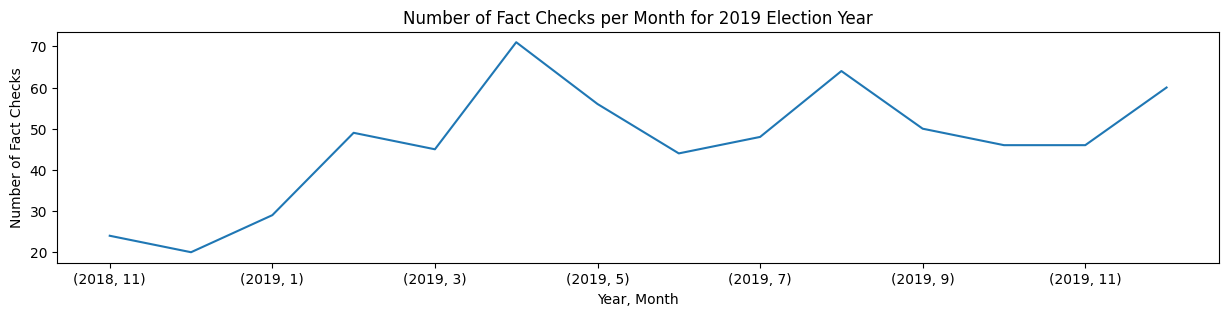

In [ ]:
# plot the distribution of number of fact checks per month for 2019 election year
plt.figure(figsize=(15, 3))
election_data_2019.groupby(['Year', 'Month']).size().plot()
plt.title('Number of Fact Checks per Month for 2019 Election Year')
plt.xlabel('Year, Month')
plt.ylabel('Number of Fact Checks')
plt.show()


In [ ]:
# election data for general election 2024
election_data_2024 = data.loc[(data['Date'] >= '2023-11-1') & (data['Date'] <='2024-12-31')]

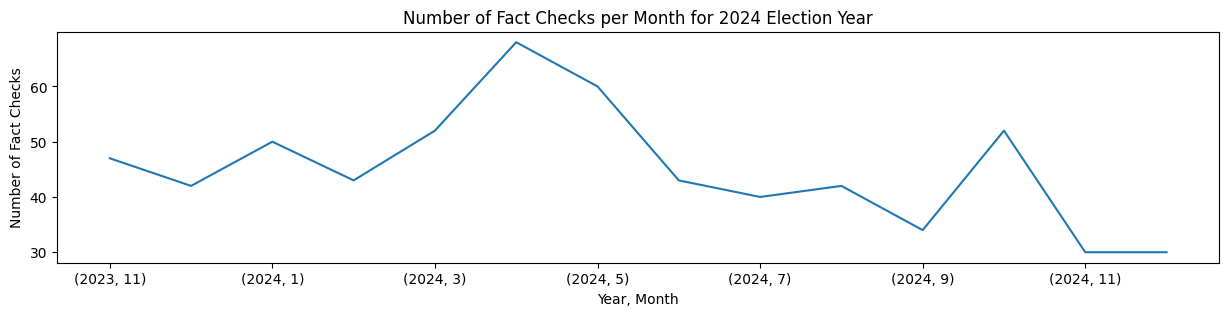

In [ ]:
# plot the distribution of number of fact checks per month for 2024 election year
plt.figure(figsize=(15, 3))
election_data_2024.groupby(['Year', 'Month']).size().plot()
plt.title('Number of Fact Checks per Month for 2024 Election Year')
plt.xlabel('Year, Month')
plt.ylabel('Number of Fact Checks')
plt.show()

In [ ]:
# shape of data
print("Shape of election_data_2019:", election_data_2019.shape)
print("Shape of election_data_2024:", election_data_2024.shape)

Shape of election_data_2019: (652, 14)
Shape of election_data_2024: (633, 14)


In [ ]:
# get the pearson correlation between the number of fact checks per month for both election cycles
elect_2019_values = election_data_2019.groupby(['Year', 'Month']).size()
elect_2024_values = election_data_2024.groupby(['Year', 'Month']).size()

In [ ]:
# reset index
elect_2019_values = elect_2019_values.reset_index()
elect_2024_values = elect_2024_values.reset_index()

In [ ]:
# pearson correlation
corr_value = elect_2019_values[0][:9].corr(elect_2024_values[0][:9], method='pearson')
print("Correlation among the number of fact checks during 2019 and 2014 election cycle:", corr_value)

Correlation among the number of fact checks during 2019 and 2014 election cycle: 0.6438676978775767


### **Topic Modeling During Election Cycles**

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
## lemmitization and stemming
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [ ]:
# preprocess the text data
# remove stopwords
stop_words = set(stopwords.words('english'))

# extract the claims
claims_2019 = election_data_2019['Claim']
claims_2024 = election_data_2024['Claim']

# Custom stopwords specific to misinformation data
custom_stopwords = {'claim', 'false', 'fake', 'video', 'social', 'image', 'media', 'online', 'showing', 'shows', 'show', 'viral',
                    'share', 'shared'}
all_stopwords = stop_words.union(custom_stopwords)

In [ ]:
# Sample data
claims_2019 = claims_2019.apply(lambda x: " ".join([word for word in x.lower().split() if word not in all_stopwords]))
claims_2024 = claims_2024.apply(lambda x: " ".join([word for word in x.lower().split() if word not in all_stopwords]))

In [ ]:
# Lemmatization
lemmatizer = WordNetLemmatizer()
claims_2019 = claims_2019.apply(lambda x: " ".join([lemmatizer.lemmatize(word) for word in x.split()]))
claims_2024 = claims_2024.apply(lambda x: " ".join([lemmatizer.lemmatize(word) for word in x.split()]))

In [ ]:
# create a list of strings of claims
claims_2019 = claims_2019.tolist()
claims_2024 = claims_2024.tolist()

In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from torch import bfloat16
import transformers
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, TextGeneration

In [ ]:
# import the embedding_model
embeddings = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

1_Pooling%2Fconfig.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### **2019 General Election**

In [ ]:
# define BERTopic model
min_topic_size = 30

BERTopic_model_2019 = BERTopic(
    embedding_model=embeddings,
    min_topic_size=min_topic_size,
    verbose=True
)

In [ ]:
# train Bertopic model
topics_2019, probs_2019 = BERTopic_model_2019.fit_transform(claims_2019)

2025-02-17 14:56:51,351 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/21 [00:00<?, ?it/s]

2025-02-17 14:57:23,954 - BERTopic - Embedding - Completed ✓
2025-02-17 14:57:23,957 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-02-17 14:57:25,423 - BERTopic - Dimensionality - Completed ✓
2025-02-17 14:57:25,425 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-02-17 14:57:25,457 - BERTopic - Cluster - Completed ✓
2025-02-17 14:57:25,463 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-02-17 14:57:25,493 - BERTopic - Representation - Completed ✓


In [ ]:
# get topic info
BERTopic_model_2019.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,232,-1_indian_claim_india_pakistan,"[indian, claim, india, pakistan, claiming, air...",[several twitter user pakistan made claim frid...
1,0,194,0_minister_gandhi_photo_party,"[minister, gandhi, photo, party, modi, congres...",[quote attributed urmila matondkar claiming fo...
2,1,190,1_old_man_muslim_police,"[old, man, muslim, police, woman, claim, attac...",[post drawing link photo injured muslim cleric...
3,2,36,2_protest_citizenship_amendment_act,"[protest, citizenship, amendment, act, student...",[claiming police force india joined protest ci...


In [ ]:
metrics = Metrics()
bert_coherence = metrics.bert_coherence(claims_2019, topics_2019, BERTopic_model_2019)

print("BERTopic Model Metrics (Coherence): ", round(bert_coherence, 5))

BERTopic Model Metrics (Coherence):  0.55388


In [ ]:
viz_embeddings = embeddings.encode(claims_2019, show_progress_bar=False)
BERTopic_model_2019.visualize_documents(claims_2019, embeddings=viz_embeddings)

In [ ]:
# top 10 words associated with each topic
BERTopic_model_2019.visualize_barchart(n_words=10)

In [ ]:
# get timestamps
dates_2019 = election_data_2019['Date']
timestamps_2019 = dates_2019.to_list()

In [ ]:
# topics over time
topics_over_time_2019 = BERTopic_model_2019.topics_over_time(claims_2019, timestamps_2019, nr_bins=20)

20it [00:00, 69.53it/s]


In [ ]:
# plot topics over time
BERTopic_model_2019.visualize_topics_over_time(topics_over_time_2019)

In [ ]:
# Analyze topic coherence
BERTopic_model_2019.visualize_hierarchy()

In [ ]:
# Extract insights
top_docs_per_topic = BERTopic_model_2019.get_representative_docs()
for topic_id, docs in top_docs_per_topic.items():
    print(f"Topic {topic_id}:")
    #print(f"Coherence: {coherence_scores[topic_id]}")
    print("Representative claims:")
    for doc in docs[:5]:
        print(f"- {doc}")
    print("\n")

Topic -1:
Representative claims:
- several twitter user pakistan made claim friday air marshal chandrashekharan hari kumar sacked, light ongoing stand-off two nations.air marshal c hari kumar, air officer commanding-in-chief, western air command indian air force retired february 28, 2019 glittering career spanning 39 years.
- bengali blog impersonating india today falsely attributed comment west bengal chief minister mamata banerjee claiming mocked indian space research organisation (isro). article blog titled india today daily news claim banerjee took dig isro taking lunar mission chandrayaan 2 ã¢ââfailing miserably.ã¢ââ
- wife indian army officer asking politicise current india pakistan tension wife indian air force pilot wing commander abhinandan varthaman.


Topic 0:
Representative claims:
- quote attributed urmila matondkar claiming former actor congress politician said prime minister narendra modi mentally ill, jibe former prime minister rajiv gandhi, false.
- old photo bhara

In [ ]:
BERTopic_model_2019.get_document_info(claims_2019)

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,terrorist nabbed punjab disguised clothes sale...,-1,-1_indian_claim_india_pakistan,"[indian, claim, india, pakistan, claiming, air...",[several twitter user pakistan made claim frid...,indian - claim - india - pakistan - claiming -...,0.000000,False
1,2014 mohanlalganj rape-murder case woman safe ...,1,1_old_man_muslim_police,"[old, man, muslim, police, woman, claim, attac...",[post drawing link photo injured muslim cleric...,old - man - muslim - police - woman - claim - ...,1.000000,False
2,virat kohli discontinuing endorsing foreign br...,0,0_minister_gandhi_photo_party,"[minister, gandhi, photo, party, modi, congres...",[quote attributed urmila matondkar claiming fo...,minister - gandhi - photo - party - modi - con...,0.867945,False
3,photo mla uttar pradesh sexually harassing poo...,1,1_old_man_muslim_police,"[old, man, muslim, police, woman, claim, attac...",[post drawing link photo injured muslim cleric...,old - man - muslim - police - woman - claim - ...,1.000000,False
4,pm narendra modi making fun suffering caused d...,0,0_minister_gandhi_photo_party,"[minister, gandhi, photo, party, modi, congres...",[quote attributed urmila matondkar claiming fo...,minister - gandhi - photo - party - modi - con...,1.000000,False
...,...,...,...,...,...,...,...,...
647,freak road accident occurred new delhi-ncr reg...,1,1_old_man_muslim_police,"[old, man, muslim, police, woman, claim, attac...",[post drawing link photo injured muslim cleric...,old - man - muslim - police - woman - claim - ...,0.879616,False
648,man appearing threatening shoot anti-citizensh...,2,2_protest_citizenship_amendment_act,"[protest, citizenship, amendment, act, student...",[claiming police force india joined protest ci...,protest - citizenship - amendment - act - stud...,1.000000,False
649,caricature depicting prime minister narendra m...,0,0_minister_gandhi_photo_party,"[minister, gandhi, photo, party, modi, congres...",[quote attributed urmila matondkar claiming fo...,minister - gandhi - photo - party - modi - con...,0.893166,False
650,police thrashing woman detention center.,1,1_old_man_muslim_police,"[old, man, muslim, police, woman, claim, attac...",[post drawing link photo injured muslim cleric...,old - man - muslim - police - woman - claim - ...,1.000000,False


### **2024 General Election**

In [ ]:
# train Bertopic on 2024 data
BERTopic_model_2024 = BERTopic(
    embedding_model=embeddings,
    min_topic_size=min_topic_size,
    verbose=True
)
topics_2024, probs_2024 = BERTopic_model_2024.fit_transform(claims_2024)

2025-02-17 15:33:38,760 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

2025-02-17 15:34:06,378 - BERTopic - Embedding - Completed ✓
2025-02-17 15:34:06,381 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-02-17 15:34:07,829 - BERTopic - Dimensionality - Completed ✓
2025-02-17 15:34:07,831 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-02-17 15:34:07,862 - BERTopic - Cluster - Completed ✓
2025-02-17 15:34:07,868 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-02-17 15:34:07,902 - BERTopic - Representation - Completed ✓


In [ ]:
# get topic info
BERTopic_model_2024.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,225,-1_hindu_old_recent_india,"[hindu, old, recent, india, man, indian, false...",[old police personnel dragging man hair surfac...
1,0,262,0_party_minister_prime_modi,"[party, minister, prime, modi, congress, naren...","[prime minister narendra modi recently, campai..."
2,1,146,1_woman_muslim_israel_hindu,"[woman, muslim, israel, hindu, israeli, group,...",[group burqa-wearing woman carrying indian fla...


In [ ]:
# top 10 words associated with each topic
BERTopic_model_2024.visualize_barchart(n_words=10)

In [ ]:
viz_embeddings_2024 = embeddings.encode(claims_2024, show_progress_bar=False)
BERTopic_model_2024.visualize_documents(claims_2024, embeddings=viz_embeddings_2024)

In [ ]:
# get the timestamps
dates_2024 = election_data_2024['Date']
timestamps_2024 = dates_2024.to_list()

In [ ]:
# topics over time
topics_over_time_2024 = BERTopic_model_2024.topics_over_time(claims_2024, timestamps_2024, nr_bins=20)

20it [00:00, 59.56it/s]


In [ ]:
BERTopic_model_2024.visualize_topics_over_time(topics_over_time_2024)

In [ ]:
# Analyze topic coherence
BERTopic_model_2024.visualize_hierarchy()

In [ ]:
# Extract insights
top_docs_per_topic = BERTopic_model_2024.get_representative_docs()
for topic_id, docs in top_docs_per_topic.items():
    print(f"Topic {topic_id}:")
    #print(f"Coherence: {coherence_scores[topic_id]}")
    print("Representative claims:")
    for doc in docs[:5]:
        print(f"- {doc}")
    print("\n")

Topic -1:
Representative claims:
- old police personnel dragging man hair surfaced x platform caption falsely stating supporter congress leader rahul gandhi mistreating sikh.
- old man military uniform making controversial remark pakistan able reach delhi within ten minute sikh soldier stationed india's border join protest, recent linked ongoing farmers' protest.
- large procession front mosque recently revived recent protest hindu ujjain, madhya pradesh, muslim allegedly chanted 'pakistan zindabad' muharram procession. state hindu urged muslim voiced support pakistan relocate pakistan. clip caption states, "in recent mukkaram procession ujjain city, muslim raised slogan pakistan zindabad. response that, next day, hindu city gathered front mosque saffron flag protested saying "those chanted 'pakistan zindabad' live here; go pakistan". unity among hindu need hour fight traitor live india whose heart beat pakistan. enemy bharat must thrown out."


Topic 0:
Representative claims:
- prime 